### Basic Info

Names: Samuel Lewis, Jake Scott, Olivia Wright
Emails & UIDS:
Sam: u12277874@utah.edu (u12277874)
Jake: u1594325@utah.edu (u1594325)
Olivia: u1491584@utah (u1491584)

### Background and Motivation

**“There are two things that are important in politics. The first is money, and I can’t remember what the second one is.”** ― Mark Hanna, U.S. Senator from Ohio and former chairman of the Republican National Committee

Recently, political discourse has become increasingly heated with an increasing amount of money being used to influence elections. According to Anna Massoglia from the Brennan Center in 2025, Super PACs spending totaled 1.9 billion for the 2024 election cycle. A Super PAC is a committee that is allowed to spend unlimited funding support or opposing candidates as long as they don't directly work with the candidates. Traditionally, PAC spending was limited to 5000 per candidate. However, in the 2010 Supreme Court case Citizens United v. The Federal Election Commission, a decision was made that donations from PACs over 5000 are allowed if they do not go directly to the intended candidate. This carved out the way for Super PAsS where donations can be as large as possible but the money has to be used independently from the candidate. This leads us to the project, where we want to analyze these Super PACs with publicly available data from the FEC.


### Project Objectives

#### How much money do candidates in political parties receive opposing them and supporting them?
##### Benefits: learn something about the popularity of candidates among donors. Does success correlate with donations for or against?
#### Are supporting or opposing donations bigger?  More common?  Etc
##### Benefits: know how donations  from these pacs are primarily being used.
#### What are the biggest Super PACs donating? Where do they primarily donate and generally how do they lean politically?
##### Benefits: know more about how these Super PACs operate
#### Which political parties receive larger single donations, or donations from a single group?  Which receives smaller donations?
##### Benefits: know whether a party receives financial support from more individual donations while overshadowed by larger contributors.
#### Does the size of a donation correlate with Republican or Democrat?
##### Benefits: know which party is financially advantaged.
#### What effect do these donations have on the current Senate?
##### Benefit: understand how donations and financial support contribute to positions held.
#### What are the differences in expenditures within swing states?
##### Benefit: learn if swing states take more money or are "battlegrounds" for Super PACs



### Data Acquisition
We will be downloading our data as a CSV file from the federal election commission __[here](https://www.fec.gov/files/bulk-downloads/2024/independent_expenditure_2024.csv)__. We also got a list of senate seats from https://www.senate.gov/senators/.

In [33]:
import pandas as pd
import re
import matplotlib.pyplot as plt

expendituresDataFrame = pd.read_csv("independentExpenditures2024.csv")
expendituresDataFrame.head()

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,...,pur,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt
0,H4CO08034,"Evans, Gabe",C00866517,Go America PAC,G,CO,8.0,H,REPUBLICAN PARTY,9000.00,...,texts supporting Gabe Evans CO-8,TTHM.com,1845617,N,E2D2833410CAA40CB9A5,202410319719900778,31-OCT-24,2024,NaN,30-OCT-24
1,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,50000.00,...,Advertising Services,Northwind Strategies,1820306,N,SE.4111,202410049684791551,04-OCT-24,2024,NaN,02-OCT-24
2,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,15000.00,...,Estimated costs of consultant work,1000 Women Strong PAC,1820306,N,SE.4109,202410049684791550,04-OCT-24,2024,NaN,02-OCT-24
3,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,7000.00,...,Production Costs for Ads,Corsair Communications,1820306,N,SE.4110,202410049684791550,04-OCT-24,2024,NaN,02-OCT-24
4,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,864.15,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN


### Ethical Considerations

Our project could affect donors, voters, and people running for governmental positions, as it could potentially affect election outcomes.  While honestly influencing an election is not inherently bad, it is potentially very impactful and could cause major changes in the lives of American constituents.  Our project could be used for harm by leveraging data to mislead others and dishonestly shift future election results.  Errors could paint certain candidates in a more positive or negative light, and lead voters who might come across our project to make uninformed or misinformed decisions. People could pick and choose, change, or misrepresent our data to skew public opinion on candidates and potentially alter the results of elections. People inappropriately misrepresent popularity, morality, and general support for candidates based solely on quantitative data.

Politics are often very morally and emotionally heavy, and with a project like this, it can be difficult to separate our personal feelings on the implications of our findings from an unbiased interpretation of results–especially when a perspective or value appears common or “obvious” enough to seem as cut and dry as the data which supports it.  We will be aware and cautious of this by avoiding imposing immediate moral implications of our data through the wording of our analysis or representation of our data (for example, avoid using terms such as “good”, “bad”, and “better” in relation to candidates).  Our goal in this project is to provide and organize information in order to provide the tools necessary to make well-informed decisions, not to convince people to make a certain decision or believe a certain way.


### Data Cleaning and Processing

As mentioned above, in Data Description and Acquisition, each item in our dataset has 24 different attributes, many of which are repetitive, extremely unlikely to be useful for our purposes, or used inconsistently enough to be effectively useless in analysis. We had to filter by alot of categories to narrow and cluster the data.

#### Filter for only Senate

In [34]:

# mask to filter for only senate candidates:
senate_mask = expendituresDataFrame["can_office"] == "S"

# applying mask to main dataframe since we are limiting our scope to only senate candidates
expendituresDataFrame = expendituresDataFrame[senate_mask].reset_index()
expendituresDataFrame.head()

,index,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,...,pur,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt
0,4,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN
1,5,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,...,Event Coordination (Estimate),DT Event Consulting,1847462,N,508110469,202411039719921574,03-NOV-24,2024,NaN,NaN
2,6,S6PA00217,"Casey, Bob",C90022559,1199 SEIU New York State Political Action Fund,G,PA,0.0,S,DEMOCRATIC PARTY,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,590110460,202410309719846856,30-OCT-24,2024,NaN,NaN
3,101,S4MD00327,"ALSOBROOKS, ANGELA",C00348540,1199 SEIU United Healthcare Workers East Feder...,G,MD,0.0,S,DEMOCRATIC PARTY,...,Radio and Digital Ad Buy and Production (Estim...,Karen Miller Consulting LLC,1832009,N,500117274,202410189698743719,18-OCT-24,2024,NaN,17-OCT-24
4,118,S4MT00183,"SHEEHY, TIM",C00881482,1889 PAC,G,MT,0.0,S,REPUBLICAN PARTY,...,"Mail Printing, Production, & Postage",Pathfinder Communications,1794189,N,SE.4113,202407079652573607,07-JUL-24,2024,NaN,05-JUL-24


#### Remove Extreme outlier
There was a extremely large expenditure of around six billion which appears to be an error in our data.

In [35]:
expendituresDataFrame = expendituresDataFrame[expendituresDataFrame['spe_nam'] != 'Republican Emo Girl'].reset_index()

#### Add Candidate Parties

In [36]:
simplified_parties = []

for row in range(len(expendituresDataFrame)):
    candidate_party = expendituresDataFrame.loc[row]["cand_pty_aff"]
    if candidate_party == "DEMOCRATIC PARTY":
        simplified_parties.append("D")
    elif candidate_party == "REPUBLICAN PARTY":
        simplified_parties.append("R")
    else:
        simplified_parties.append("O")

expendituresDataFrame["cand_pty_aff_simpl"] = simplified_parties
expendituresDataFrame.head()

,level_0,index,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,...,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt,cand_pty_aff_simpl
0,0,4,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN,D
1,1,5,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,...,DT Event Consulting,1847462,N,508110469,202411039719921574,03-NOV-24,2024,NaN,NaN,D
2,2,6,S6PA00217,"Casey, Bob",C90022559,1199 SEIU New York State Political Action Fund,G,PA,0.0,S,...,Pendulum Creative Group,1845172,N,590110460,202410309719846856,30-OCT-24,2024,NaN,NaN,D
3,3,101,S4MD00327,"ALSOBROOKS, ANGELA",C00348540,1199 SEIU United Healthcare Workers East Feder...,G,MD,0.0,S,...,Karen Miller Consulting LLC,1832009,N,500117274,202410189698743719,18-OCT-24,2024,NaN,17-OCT-24,D
4,4,118,S4MT00183,"SHEEHY, TIM",C00881482,1889 PAC,G,MT,0.0,S,...,Pathfinder Communications,1794189,N,SE.4113,202407079652573607,07-JUL-24,2024,NaN,05-JUL-24,R


#### Filter by party

In [37]:
# LIV - CREATE MASK FOR REPUBLICAN AND DEMOCRAT
# republican_mask = if republican True
# democrat_mask = if democrat True
# no_other_mask = republican and democrat candidates only (omit "other" candidates)
republican_mask = expendituresDataFrame["cand_pty_aff_simpl"] == "R"
democrat_mask = expendituresDataFrame["cand_pty_aff_simpl"] == "D"
no_other_mask = expendituresDataFrame["cand_pty_aff_simpl"] != "O"

# # testing republican_mask
# expendituresDataFrame[republican_mask].head(10)
# print("republican_mask")
# print("Expecting 6301, got " + str(len(expendituresDataFrame[republican_mask])))

# # testing democrat_mask
# expendituresDataFrame[democrat_mask].head(10)
# print("democrat_mask")
# print("Expecting 9418, got " + str(len(expendituresDataFrame[democrat_mask])))

# # testing no_other_mask
# expendituresDataFrame[no_other_mask].head(10)
# print("no_other_mask")
# print("Expecting 15719, got " + str(len(expendituresDataFrame[no_other_mask])))

#### Standardize the names and IDs

In [38]:
def clean_candidate_name(name):
    if pd.isna(name):
        return None

    name = name.upper().strip()
    # remove punctuation
    name = re.sub(r"[.,]", "", name)
    # normalize spaces
    name = re.sub(r"\s+", " ", name)
    words = name.split()
    remove_words = {"JR", "SR", "II", "III", "IV", "V", "I", "JUSTICE", "DR", "HON", "MR", "MRS", "MS"}
    words = [word for word in words if len(word) > 1 and word not in remove_words]
    return " ".join(words)

expendituresDataFrame["cand_name_clean"]=expendituresDataFrame["cand_name"].apply(clean_candidate_name)

print("Before:", expendituresDataFrame["cand_name"].nunique())
print("After:", expendituresDataFrame["cand_name_clean"].nunique())
unique_candidate_ids = expendituresDataFrame["cand_id"].dropna().unique()
print(len(unique_candidate_ids))

expendituresDataFrame["exp_amo"] = pd.to_numeric(expendituresDataFrame["exp_amo"], errors="coerce")

Before: 215
After: 143
129


#### Add Senators

In [39]:
# list of senators:
current_senator_names = ["TUBERVILLE, TOMMY", "BRITT, KATIE", "MURKOWSKI, LISA", "SULLIVAN, DAN", "KELLY, MARK", "GALLEGO, RUBEN", "BOOZMAN, JOHN", "COTTON, TOM", "PADILLA, ALEX", "SCHIFF, ADAM","BENNET, MICHAEL", "HICKENLOOPER, JOHN", "BLUMENTHAL, RICHARD", "MURPHY, CHRIS", "COONS, CHRIS", "BLUNT ROCHESTER, LISA", "SCOTT, RICK", "MOODY, ASHLEY", "OSSOFF, JON", "WARNOCK, RAPHAEL", "SCHATZ, BRIAN", "HIRONO, MAZIE", "CRAPO, MIKE", "RISCH, JIM", "DURBIN, RICHARD", "DUCKWORTH, TAMMY", "YOUNG, TODD", "BANKS, JIM", "GRASSLEY, CHUCK", "ERNST, JONI", "MORAN, JERRY", "MARSHALL, ROGER", "MCCONNELL, MITCH", "PAUL, RAND", "CASSIDY, BILL", "KENNEDY, JOHN", "COLLINS, SUSAN", "KING, ANGUS", "VAN HOLLEN, CHRIS", "ALSOBROOKS, ANGELA", "WARREN, ELIZABETH", "MARKEY, ED", "PETERS, GARY", "SLOTKIN, ELISSA", "KLOBUCHAR, AMY", "SMITH TINA", "WICKER, ROGER", "HYDE-SMITH, CINDY", "HAWLEY, JOSH", "SCHMITT, ERIC", "DAINES, STEVE", "SHEEHY, TIM", "FISCHER, DEB", "RICKETTS,PETE", "CORTEZ MASTO, CATHERINE", "ROSEN, JACKY", "SHAHEEN, JEANNE", "HASSAN, MAGGIE", "BOOKER, CORY", "KIM, ANDY", "HEINRICH, MARTIN", "LUJAN, BEN RAY", "SCHUMER, CHUCK", "GILLIBRAND, KIRSTEN", "TILLIS, THOM", "BUDD, TED", "HOEVEN, JOHN", "CRAMER, KEVIN", "MORENO, BERNIE", "HUSTED, JON", "LANKFORD, JAMES", "ARMSTRONG, ALAN", "WYDEN, RON", "MERKLEY, JEFF", "FETTERMAN, JOHN", "MCCORMICK, DAVE", "REED, JACK", "WHITEHOUSE, SHELDON", "GRAHAM, LINDSEY", "SCOTT, TIM", "THUNE, JOHN", "ROUNDS, MIKE", "BLACKBURN, MARSHA", "HAGERTY, BILL", "CORNYN, JOHN", "CRUZ, TED", "LEE, MIKE", "CURTIS, JOHN", "SANDERS, BERNIE", "WELCH, PETER", "WARNER, MARK", "KAINE, TIM", "MURRAY, PATTY", "CANTWELL, MARIA", "CAPITO, SHELLEY MOORE", "JUSTICE, JIM", "JOHNSON, RON", "BALDWIN, TAMMY", "BARRASSO, JOHN", "LUMMIS, CYNTHIA"]

current_senator_states = ["AL", "AL", "AK", "AK", "AZ", "AZ", "AR", "AR", "CA", "CA", "CO", "CO", "CT", "CT", "DE", "DE", "FL", "FL", "GA", "GA", "HI", "HI", "ID", "ID", "IL", "IL", "IN", "IN", "IA", "IA", "KS", "KS", "KY", "KY", "LA", "LA", "ME", "ME", "MD", "MD", "MA", "MA", "MI", "MI", "MN", "MN", "MS", "MS", "MO", "MO", "MT", "MT", "NE", "NE", "NV", "NV", "NH", "NH", "NJ", "NJ", "NM", "NM", "NY", "NY", "NC", "NC", "ND", "ND", "OH", "OH", "OK", "OK", "OR", "OR", "PA", "PA", "RI", "RI", "SC", "SC", "SD", "SD", "TN", "TN", "TX", "TX", "UT", "UT", "VT", "VT", "VA", "VA", "WA", "WA", "WV", "WV", "WI", "WI", "WY", "WY"]

current_senator_parties = ["R", "R", "R", "R", "D", "D", "R", "R", "D", "D", "D", "D", "D", "D", "D", "D", "R", "R", "D", "D", "D", "D", "R", "R", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "R", "R", "R", "O", "D", "D", "D", "D", "D", "D", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "D", "D", "D", "D", "D", "D","D", "D", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "D", "D", "D", "R", "D", "D", "R", "R", "R", "R", "R", "R", "R", "R", "R", "R", "O", "D", "D", "D", "D", "D", "R", "R", "R", "D", "R", "R"]

current_senator_genders = ["M", "F", "F", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "F", "M", "F", "M", "M", "M", "F", "M", "M", "M", "F", "M", "M", "M", "F", "M", "M", "M", "M", "M", "M", "F", "M", "M", "F", "F", "M", "M", "F", "F", "F", "M", "F", "M", "M", "M", "M", "F", "M", "F", "F", "F", "F", "M", "M", "M", "M", "M", "F", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "M", "F", "M", "M", "M", "M", "M", "M", "M", "M", "M", "F", "F", "F", "M", "M", "F", "M", "F"]

current_senators_df = pd.DataFrame({"name" : current_senator_names, "state" : current_senator_states, "party" : current_senator_parties, "gender" : current_senator_genders})
current_senators_df = current_senators_df.set_index("name")
# checking entries
print("number republican senators")
print("expecting: 53")
print("got: " + str(len(current_senators_df[current_senators_df["party"] == "R"])))
print("number democratic senators")
print("expecting: 45")
print("got: " + str(len(current_senators_df[current_senators_df["party"] == "D"])))
print()
print("number male senators")
print("expecting: 74")
print("got: " + str(len(current_senators_df[current_senators_df["gender"] == "M"])))
print()
print("number female senators")
print("expecting: 26")
print("got: " + str(len(current_senators_df[current_senators_df["gender"] == "F"])))

democratic_current_senators_df = (current_senators_df[current_senators_df["party"] == "D"])
republican_current_senators_df = (current_senators_df[current_senators_df["party"] == "R"])


number republican senators
expecting: 53
got: 53
number democratic senators
expecting: 45
got: 45

number male senators
expecting: 74
got: 74

number female senators
expecting: 26
got: 26


#### Filter by donation size

In [40]:
#Sam - Create a new column for supporting/opposing converted to true/false (let supporting = true opposing = false)
expendituresDataFrame["is_support"] = expendituresDataFrame["sup_opp"] == "S"

largeDonationCutoff = 1000000 #1,000,000
#Sam - Create a new data frame with just donations > largeDonationCutoff
largeDonationsDF = expendituresDataFrame[expendituresDataFrame["exp_amo"] > largeDonationCutoff]

#### Filter by States (including swing States)

In [41]:

swing_states = ["AZ", "GA", "MI", "NV", "NC", "PA", "WI"]
republican_states = ["AL", "AK", "AR", "FL", "ID", "IN", "IA", "KS", "KY", "LA", "MS", "MO", "MT", "NE", "ND", "OH", "OK", "SC", "SD", "TN", "TX", "UT", "WV", "WY"]
democratic_states = ["CA", "CO", "CT", "DE", "HI", "IL", "ME", "MD", "MA", "MN", "NH", "NJ", "NM", "NY", "OR", "RI", "VA", "VT", "WA"]


#### Filter by donations
We decided to filter by size of expenditures (greater than 1$ million). We also created a new attribute called true_party to capture the expenditures party leaning. An expenditure opposing a democratic candidate would be considered a republican expenditure.

In [42]:

democratOrRepublicanDF = expendituresDataFrame[
    expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])
].copy()

def trueParty(row):
    isRep = row["cand_pty_aff"] == "REPUBLICAN PARTY"
    if row["is_support"]:
        return "REPUBLICAN PARTY" if isRep else "DEMOCRATIC PARTY"
    else:
        return "DEMOCRATIC PARTY" if isRep else "REPUBLICAN PARTY"

democratOrRepublicanDF["true_party"] = democratOrRepublicanDF.apply(trueParty, axis=1)

trueRepublicanExpendituresDataFrame = democratOrRepublicanDF[democratOrRepublicanDF["true_party"] == "REPUBLICAN PARTY"]
trueDemocratExpendituresDataFrame   = democratOrRepublicanDF[democratOrRepublicanDF["true_party"] == "DEMOCRATIC PARTY"]

largeTrueRepublicanExpendituresDataFrame = trueRepublicanExpendituresDataFrame[
    trueRepublicanExpendituresDataFrame["exp_amo"] > largeDonationCutoff
]
largeTrueDemocratExpendituresDataFrame = trueDemocratExpendituresDataFrame[
    trueDemocratExpendituresDataFrame["exp_amo"] > largeDonationCutoff
]

print("True Republican total:", trueRepublicanExpendituresDataFrame["exp_amo"].sum())
print("True Democrat total:  ", trueDemocratExpendituresDataFrame["exp_amo"].sum())

republicanExpendituresDataFrame = expendituresDataFrame[expendituresDataFrame['cand_pty_aff'] == "REPUBLICAN PARTY"] #Donations to republican candidates either supposing or opposing
democratExpendituresDataFrame = expendituresDataFrame[expendituresDataFrame['cand_pty_aff'] == "DEMOCRATIC PARTY"] #Donations to democratic candidates either supposing or opposing

largeRepublicanExpendituresDataFrame = republicanExpendituresDataFrame[republicanExpendituresDataFrame['exp_amo'] > largeDonationCutoff]
largeDemocratExpendituresDataFrame = democratExpendituresDataFrame[democratExpendituresDataFrame['exp_amo'] > largeDonationCutoff]
print("Republican total:", republicanExpendituresDataFrame["exp_amo"].sum())
print("Democrat total:  ", democratExpendituresDataFrame["exp_amo"].sum())



True Republican total: 766429327.9200001
True Democrat total:   599130313.6400001
Republican total: 666630494.25
Democrat total:   698929147.3100001


### Exploratory Analysis, Analysis Methodology, and Project Questions

#### How much money do candidates in political parties receive opposing them and supporting them? What are their largest donors?
We are still working on this.

#### Top 5 biggest spenders by party

Top 5 Spenders for Democratic Candidates:
                    spe_nam       exp_amo
179  Senate Leadership Fund  1.972257e+08
15      American Crossroads  5.997458e+07
91     KEYSTONE RENEWAL PAC  4.133314e+07
210         WIN IT BACK PAC  4.021808e+07
100       MARYLAND'S FUTURE  3.120674e+07



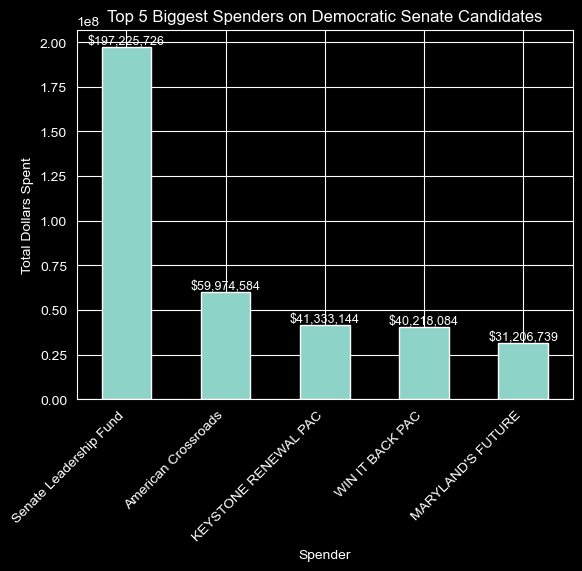

Top 5 Spenders for Republican Candidates:
                                               spe_nam       exp_amo
409                                          WinSenate  2.908055e+08
272                               DEFEND AMERICAN JOBS  5.115485e+07
246  Americans for Prosperity Action, Inc. (AFP Act...  4.828077e+07
281                                               DSCC  4.375485e+07
320                                Last Best Place PAC  3.202758e+07



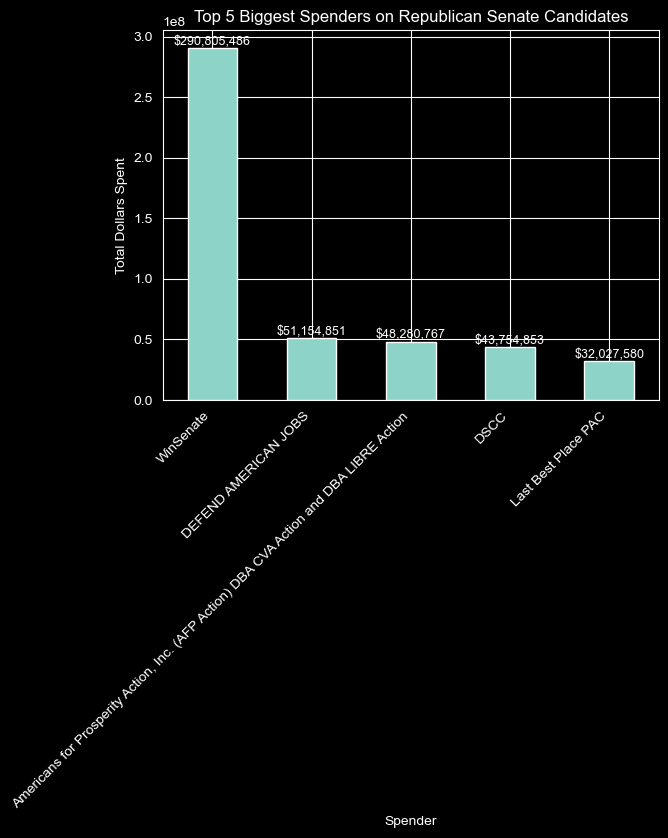

In [43]:
# just keep democratic and republican candidates
dem_rep_df = expendituresDataFrame[expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])].copy()

# group by PAC name and party
spender_totals = dem_rep_df.groupby(["cand_pty_aff", "spe_nam"])["exp_amo"].sum().reset_index()

# top 5 spenders for democrats
top5_dem = spender_totals[spender_totals["cand_pty_aff"] == "DEMOCRATIC PARTY"] \
    .sort_values("exp_amo", ascending=False) \
    .head(5)
print("Top 5 Spenders for Democratic Candidates:")
print(top5_dem[["spe_nam", "exp_amo"]])
print()
# democrat spender graph
ax = top5_dem.plot(kind="bar", x="spe_nam", y="exp_amo", legend=False)

plt.title("Top 5 Biggest Spenders on Democratic Senate Candidates")
plt.xlabel("Spender")
plt.ylabel("Total Dollars Spent")
plt.xticks(rotation=45, ha="right")
# total spending labels above bars
for i, value in enumerate(top5_dem["exp_amo"]):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

# top 5 spenders for republicans
top5_rep = spender_totals[spender_totals["cand_pty_aff"] == "REPUBLICAN PARTY"] \
    .sort_values("exp_amo", ascending=False) \
    .head(5)

print("Top 5 Spenders for Republican Candidates:")
print(top5_rep[["spe_nam", "exp_amo"]])
print()
# republican spender graph
ax = top5_rep.plot(kind="bar", x="spe_nam", y="exp_amo", legend=False)

plt.title("Top 5 Biggest Spenders on Republican Senate Candidates")
plt.xlabel("Spender")
plt.ylabel("Total Dollars Spent")
plt.xticks(rotation=45, ha="right")
# total spending labels above bars
for i, value in enumerate(top5_rep["exp_amo"]):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

#### Are supporting or opposing expenditures bigger?

Total Spending:
is_support
False    1.012636e+09
True     4.042900e+08
Name: exp_amo, dtype: float64



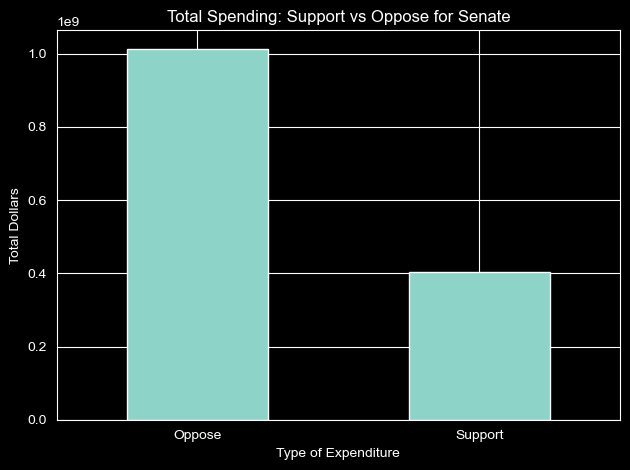

In [44]:
total_spending = expendituresDataFrame.groupby("is_support")["exp_amo"].sum()
print("Total Spending:")
print(total_spending)
print()
# total spending graph
total_spending.index = ["Oppose", "Support"]
total_spending.plot(kind="bar")
plt.title("Total Spending: Support vs Oppose for Senate")
plt.xlabel("Type of Expenditure")
plt.ylabel("Total Dollars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Are supporting or opposing expenditures more common?

Number of Expenditures:
is_support
True     12889
False     4128
Name: count, dtype: int64



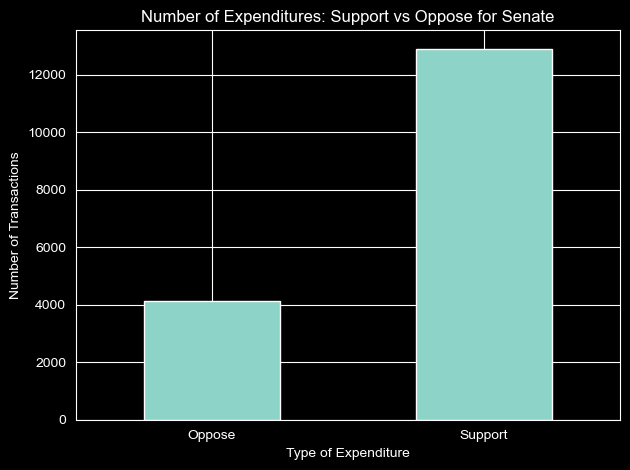

In [45]:
count_spending = expendituresDataFrame["is_support"].value_counts()

print("Number of Expenditures:")
print(count_spending)
print()
# Number of expenditures graph
count_spending = count_spending.sort_index()
count_spending.index = ["Oppose", "Support"]
count_spending.plot(kind="bar")
plt.title("Number of Expenditures: Support vs Oppose for Senate")
plt.xlabel("Type of Expenditure")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### How does spending lean politically?

Spending by Party and Support/Oppose:
cand_pty_aff_simpl  is_support
D                   False         5.492033e+08
                    True          1.497258e+08
O                   False         1.402833e+07
                    True          3.733824e+07
R                   False         4.494045e+08
                    True          2.172260e+08
Name: exp_amo, dtype: float64



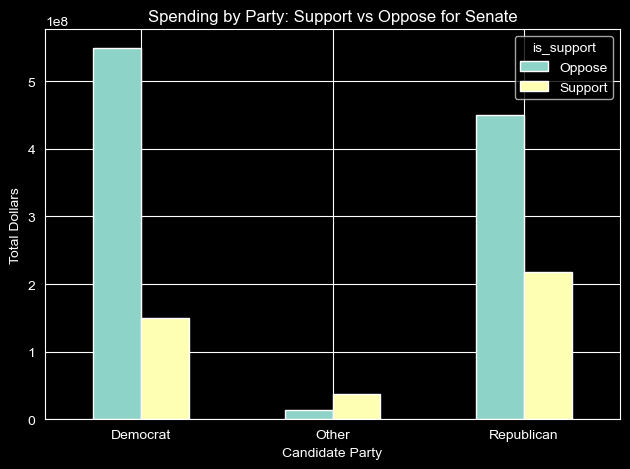

In [46]:
party_spending = expendituresDataFrame.groupby(["cand_pty_aff_simpl", "is_support"])["exp_amo"].sum()

print("Spending by Party and Support/Oppose:")
print(party_spending)
print()

# Convert to table format and rename columns
plot_df = party_spending.unstack().rename(columns={False: "Oppose", True: "Support"})

# Rename index labels (this is what changes the tick labels)
plot_df = plot_df.rename(index={"D": "Democrat", "R": "Republican", "O": "Other"})

# spending by party graph
plot_df.plot(kind="bar")
plt.title("Spending by Party: Support vs Oppose for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Total Dollars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Net spending on parties

Democrat vs Republican Support/Oppose Spending:
is_support              Oppose       Support  Net Spending
cand_pty_aff                                              
DEMOCRATIC PARTY  5.492033e+08  1.497258e+08 -3.994775e+08
REPUBLICAN PARTY  4.494045e+08  2.172260e+08 -2.321785e+08



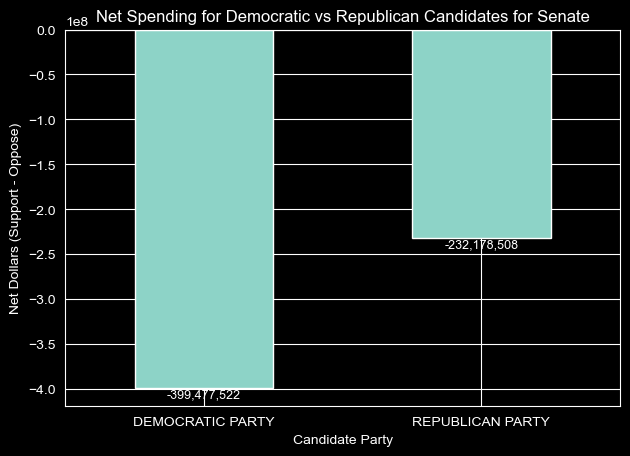

In [47]:
# net spending = support - oppose
dem_rep_df = expendituresDataFrame[expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])].copy()
# group support and oppose spending
dem_rep_support_opp = dem_rep_df.groupby(["cand_pty_aff", "is_support"])["exp_amo"].sum().unstack(fill_value=0)
# rename columns to look better
dem_rep_support_opp = dem_rep_support_opp.rename(columns={False: "Oppose", True: "Support"})
# net spending
dem_rep_support_opp["Net Spending"] = dem_rep_support_opp["Support"] - dem_rep_support_opp["Oppose"]

print("Democrat vs Republican Support/Oppose Spending:")
print(dem_rep_support_opp)
print()
# net spending graph
ax = dem_rep_support_opp["Net Spending"].plot(kind="bar")
plt.title("Net Spending for Democratic vs Republican Candidates for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Net Dollars (Support - Oppose)")
plt.xticks(rotation=0)
plt.axhline(0)
# net spending labels
for i, value in enumerate(dem_rep_support_opp["Net Spending"]):
    if value >= 0:
        ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=9)
    else:
        ax.text(i, value, f"{value:,.0f}", ha="center", va="top", fontsize=9)

plt.tight_layout()
plt.show()

#### Which political parties receive larger single donations, or donations from a single group?  Which receives smaller donations? Which receives a higher quantity of donations?
We are still working on this.

#### Does the size of a donation correlate with Republican or Democrat?
We are still working on this.

#### What effect do these donations have on the current Senate?
We are still working on this. Make this into its own section, too many questions to answer.


In [48]:
# to do:
# add a column to current_senators_df with total amount of PAC money received for, total amount of PAC money received against, number of pac donations for/against, average amount of money per pac donation, using data from main dataframe

# whoever was in charge of names, we still need to account for capitalization differences.

# for senator in current_senator_names:
#     if
#     senator_mask = expendituresDataFrame["cand_name"] == senator



# MUST DOUBLE CHECK THAT ALL NAMES APPEAR ONLY ONCE
# questions for this section (scope only for the current senators):
# is there a relationship between PAC donations and gender of the candidate?
# relationship between parties in current senate and pacs
# how is this relationship different from parties overall
# are the average/median/etc of amounts of money/donations different for current members
# (careful with correlation vs causation)
# remember to account for current senators who received no pac donations (and therefore won't be on the main dataframe)


# senator_mask = expendituresDataFrame["cand_name"].groupby("cand_name")
# pd.set_option("display.max_columns", None)
# test_senator_mask = expendituresDataFrame["cand_name"] == "ALSOBROOKS, ANGELA"
# expendituresDataFrame[test_senator_mask].head()

#### How do swing states differ than non swing states?

Total spending by state:
   state  total_spending state_group
32    OH    3.141112e+08  Republican
34    PA    2.437889e+08       Swing
22    MT    1.702232e+08  Republican
18    MI    1.456032e+08       Swing
42    WI    1.240836e+08       Swing
30    NV    1.062022e+08       Swing
2     AZ    8.064944e+07       Swing
38    TX    6.076690e+07  Republican
16    MD    5.675728e+07  Democratic
26    NE    3.129331e+07  Republican
3     CA    2.499922e+07  Democratic
39    UT    1.685594e+07  Republican
7     FL    1.106355e+07  Republican
43    WV    8.088527e+06  Republican
20    MO    4.456665e+06  Republican
12    IN    4.218781e+06  Republican
29    NM    4.075653e+06  Democratic
15    MA    2.111275e+06  Democratic
28    NJ    1.899095e+06  Democratic
37    TN    1.163468e+06  Republican
44    WY    1.007628e+06  Republican
40    VA    6.884924e+05  Democratic
8     GA    5.988017e+05       Swing
21    MS    4.700500e+05  Republican
35    RI    3.485373e+05  Democratic
33    OK    2

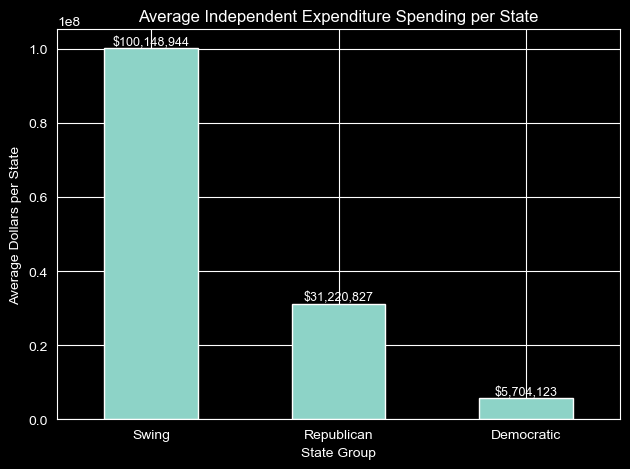

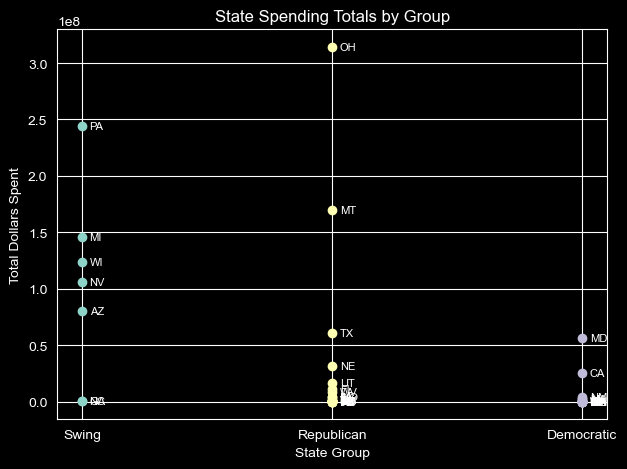

In [49]:
# total spending by state
state_totals = expendituresDataFrame.groupby("can_office_state")["exp_amo"].sum().reset_index()
state_totals.columns = ["state", "total_spending"]

# classify state into republican, democrat, or swing
def classify_state(state):
    if state in swing_states:
        return "Swing"
    elif state in republican_states:
        return "Republican"
    elif state in democratic_states:
        return "Democratic"
    else:
        return "Other"
state_totals["state_group"] = state_totals["state"].apply(classify_state)


print("Total spending by state:")
print(state_totals.sort_values("total_spending", ascending=False))
print()

# average spending per state for each group
group_avg = state_totals.groupby("state_group")["total_spending"].mean().reindex(["Swing", "Republican", "Democratic"])

print("Average spending per state by group:")
print(group_avg)
print()

# total spending and number of states in each group
group_summary = state_totals.groupby("state_group").agg(average_spending=("total_spending", "mean"),total_spending=("total_spending", "sum"),number_of_states=("state", "count")).reindex(["Swing", "Republican", "Democratic"])

print("Summary by group:")
print(group_summary)
print()

# Average spending per state bar graph
ax = group_avg.plot(kind="bar")
plt.title("Average Independent Expenditure Spending per State")
plt.xlabel("State Group")
plt.ylabel("Average Dollars per State")
plt.xticks(rotation=0)
for i, value in enumerate(group_avg):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Individual state totals dot graph
# driven by only a few states
group_order = ["Swing", "Republican", "Democratic"]
x_positions = {group: i for i, group in enumerate(group_order)}

for group in group_order:
    group_data = state_totals[state_totals["state_group"] == group]
    x_vals = [x_positions[group]] * len(group_data)
    plt.scatter(x_vals, group_data["total_spending"])

    # label each point with the state abbreviation
    for _, row in group_data.iterrows():
        plt.text( x_positions[group] + 0.03, row["total_spending"], row["state"], fontsize=8, va="center")

plt.xticks([0, 1, 2], group_order)
plt.title("State Spending Totals by Group")
plt.xlabel("State Group")
plt.ylabel("Total Dollars Spent")
plt.tight_layout()
plt.show()

#### Where do donations differ?

In [50]:
print("The number of Republican SUPER PACs expenditures from 2022-24 is " + str(republicanExpendituresDataFrame.size))
print("The number of Democrat SUPER PACs expenditures from 2022-24 is " + str(democratExpendituresDataFrame.size))

print("The number of large Republican SUPER PACs expenditures (>$1,000,000) from 2022-24 is " + str(largeRepublicanExpendituresDataFrame.size))
print("The number of large Democrat SUPER PACs expenditures (>$1,000,000) from 2022-24 is " + str(largeDemocratExpendituresDataFrame.size))


totalRepublicanExpenditures = republicanExpendituresDataFrame['exp_amo'].sum()
totalDemocratExpenditures = democratExpendituresDataFrame['exp_amo'].sum()

totalLargeRepublicanExpenditures = largeRepublicanExpendituresDataFrame['exp_amo'].sum()
totalLargeDemocratExpenditures = largeDemocratExpendituresDataFrame['exp_amo'].sum()


print(f"The sum of all large republican expenditures was {totalLargeRepublicanExpenditures}")
print(f"The sum of all large democrat expenditures was {totalLargeDemocratExpenditures}")



The number of Republican SUPER PACs expenditures from 2022-24 is 176400
The number of Democrat SUPER PACs expenditures from 2022-24 is 263704
The number of large Republican SUPER PACs expenditures (>$1,000,000) from 2022-24 is 4872
The number of large Democrat SUPER PACs expenditures (>$1,000,000) from 2022-24 is 5236
The sum of all large republican expenditures was 384850326.15
The sum of all large democrat expenditures was 441851678.11


### List of Completed Milestones & Method Milestones
#### Completed Milestones
Project Description
Data Description
Ethical Data Concerns
Peer Feedback
Summary

#### Method Milestones
Where do donations differ?
How do swing states differ than non-swing states?
Net spending on parties
How does spending lean politically?
Are supporting or opposing expenditures more common?
Are supporting or opposing expenditures bigger?
What are the biggest spenders by party?

We still have a few questions to answer

### Summary
With our preliminary results, Republicans received less money opposing them and more money supporting them. Democrats received more money opposing them and less money supporting them. There was a substantial amount of donations in our data totaling $1,365,559,640.